# New Baselines & Structural Comparison — Facebook Ego Networks

Same analysis as notebook 01 (Twitch), now applied to the **10 Facebook ego networks**.

These networks are smaller (52–1,034 nodes) and represent reciprocal friendship ties,
where the BA model dominated in the original paper (Table 2). We test whether the new
baselines (SBM, Configuration Model, Chung-Lu) change the picture.

Addresses reviewer concerns **W3** (non-spectral evaluation), **W4** (structural metrics),
and **W5** (missing baselines).

In [13]:
import sys, os, warnings, pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import ks_2samp

sys.path.insert(0, os.path.abspath('../..'))
from src.logit_graph.simulation import (
    LogitGraphFitter, LogitGraphSimulation,
    estimate_sigma_only, calculate_graph_attributes,
)
from src.logit_graph import gic

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 14,
    'axes.titlesize': 16, 'axes.labelsize': 14,
    'figure.figsize': (14, 6),
})

SEED = 42
np.random.seed(SEED)
OUT_DIR = 'runs'
os.makedirs(OUT_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Helper Functions

Identical to notebook 01 — structural features, model generators, GIC wrapper.

In [14]:
def compute_structural_features(G, max_path_nodes=3000, seed=42):
    feats = {}
    n, m = G.number_of_nodes(), G.number_of_edges()
    feats['nodes'], feats['edges'] = n, m
    feats['density'] = nx.density(G)

    degrees = [d for _, d in G.degree()]
    feats['avg_degree'] = np.mean(degrees)
    feats['std_degree'] = np.std(degrees)
    feats['max_degree'] = max(degrees) if degrees else 0
    feats['degree_skewness'] = float(pd.Series(degrees).skew()) if len(degrees) > 2 else 0.0

    feats['avg_clustering'] = nx.average_clustering(G)
    feats['transitivity'] = nx.transitivity(G)

    try:
        feats['assortativity'] = nx.degree_assortativity_coefficient(G)
    except Exception:
        feats['assortativity'] = np.nan

    feats['triangles'] = sum(nx.triangles(G).values()) // 3

    components = list(nx.connected_components(G))
    feats['num_components'] = len(components)
    largest_cc = max(components, key=len)
    feats['largest_cc_fraction'] = len(largest_cc) / n

    if len(largest_cc) > 1 and len(largest_cc) <= max_path_nodes:
        sub = G.subgraph(largest_cc)
        feats['avg_path_length'] = nx.average_shortest_path_length(sub)
        feats['diameter'] = nx.diameter(sub)
    else:
        feats['avg_path_length'] = np.nan
        feats['diameter'] = np.nan

    try:
        comms = nx.community.louvain_communities(G, seed=seed)
        feats['modularity'] = nx.community.modularity(G, comms)
        feats['n_communities'] = len(comms)
    except Exception:
        feats['modularity'] = np.nan
        feats['n_communities'] = np.nan

    return feats


def degree_ks_stat(G_real, G_model):
    stat, _ = ks_2samp([d for _, d in G_real.degree()], [d for _, d in G_model.degree()])
    return stat


def compute_gic_value(G_real, G_model, n_params):
    try:
        calc = gic.GraphInformationCriterion(
            graph=G_real, model='LG', log_graph=G_model, dist='KL'
        )
        return calc.calculate_gic(n_params=n_params)
    except Exception as e:
        print(f'    GIC error: {e}')
        return np.nan

print('Helper functions defined.')

Helper functions defined.


In [15]:
def generate_sbm(G_real, seed=None):
    comms = list(nx.community.louvain_communities(G_real, seed=seed))
    sizes = [len(c) for c in comms]
    k = len(comms)
    comm_nodes = [sorted(c) for c in comms]

    p_matrix = np.zeros((k, k))
    for ci in range(k):
        for cj in range(ci, k):
            ni, nj = comm_nodes[ci], comm_nodes[cj]
            if ci == cj:
                possible = len(ni) * (len(ni) - 1) / 2
                actual = sum(1 for u in ni for v in ni if u < v and G_real.has_edge(u, v))
            else:
                possible = len(ni) * len(nj)
                actual = sum(1 for u in ni for v in nj if G_real.has_edge(u, v))
            p_matrix[ci, cj] = actual / possible if possible > 0 else 0
            p_matrix[cj, ci] = p_matrix[ci, cj]

    sbm = nx.stochastic_block_model(sizes, p_matrix.tolist(), seed=seed)
    G_out = nx.Graph()
    G_out.add_nodes_from(range(sum(sizes)))
    G_out.add_edges_from(sbm.edges())
    n_params = k * (k + 1) // 2
    return G_out, n_params


def generate_config_model(G_real, seed=None):
    deg_seq = [d for _, d in G_real.degree()]
    if sum(deg_seq) % 2 != 0:
        deg_seq[0] += 1
    G_cm = nx.configuration_model(deg_seq, seed=seed)
    G_cm = nx.Graph(G_cm)
    G_cm.remove_edges_from(nx.selfloop_edges(G_cm))
    return G_cm, 1


def generate_chung_lu(G_real, seed=None):
    deg_seq = [d for _, d in G_real.degree()]
    G_cl = nx.expected_degree_graph(deg_seq, seed=seed, selfloops=False)
    return G_cl, 1


def generate_er(G_real, seed=None):
    return nx.erdos_renyi_graph(G_real.number_of_nodes(), nx.density(G_real), seed=seed), 1


def generate_ba(G_real, seed=None):
    avg_k = 2 * G_real.number_of_edges() / G_real.number_of_nodes()
    m = max(1, int(round(avg_k / 2)))
    return nx.barabasi_albert_graph(G_real.number_of_nodes(), m, seed=seed), 1


def generate_ws(G_real, seed=None):
    n = G_real.number_of_nodes()
    avg_k = 2 * G_real.number_of_edges() / n
    k = max(2, int(round(avg_k)))
    if k % 2 != 0:
        k += 1
    k = min(k, n - 1)
    return nx.watts_strogatz_graph(n, k, 0.1, seed=seed), 2


def estimate_lg_params(adj, d):
    """Estimate sigma AND beta jointly (fix_beta=False).

    With fix_beta=True the coefficient of S_i+S_j is forced to 1, but the
    raw degree-sum features in dense ego networks are so large that the
    logistic function saturates.  Estimating beta freely yields a small
    scaling factor (e.g. 0.05) and a sigma in the [-10, -2] range
    consistent with the paper's Table 3.
    """
    from src.logit_graph.logit_estimator import LogitRegEstimator
    est = LogitRegEstimator(adj, d=d, verbose=False)
    features, labels = est.get_features_labels()
    _, params, _ = est.estimate_parameters(
        features=features, labels=labels, fix_beta=False, alpha=0,
    )
    sigma, beta = float(params[0]), float(params[1])
    return sigma, beta


from src.logit_graph.graph import GraphModel


def simulate_lg(n, d, sigma, beta, G_real, init_graph=None,
                max_iter=15000, check_interval=50, er_p=0.05,
                patience=200, min_gic_threshold=-1.0, edge_delta_frac=0.3,
                verbose=False):
    """Spectrum-guided LG MCMC (consistent with paper's LogitGraphFitter).

    Key improvements over the baseline-only version:
    1. Uses populate_edges_spectrum_min_gic → targets the real graph's spectrum
    2. edge_delta guard prevents runaway edge counts
    3. Accepts init_graph for structured initialization (e.g. Chung-Lu)
       which preserves degree distribution and provides clustering seed
    """
    gm = GraphModel(n=n, d=d, sigma=sigma, alpha=1.0, beta=beta,
                    er_p=er_p, init_graph=init_graph)

    real_edges = G_real.number_of_edges()
    edge_delta = max(int(real_edges * edge_delta_frac), 100)

    graphs, spectra, spectrum_diffs, best_iter, best_graph, gic_values = \
        gm.populate_edges_spectrum_min_gic(
            max_iterations=max_iter,
            patience=patience,
            real_graph=G_real,
            min_gic_threshold=min_gic_threshold,
            check_interval=check_interval,
            verbose=verbose,
            er_p=er_p,
            edge_delta=edge_delta,
        )

    conv = {
        'iterations': [i * check_interval for i in range(len(spectrum_diffs))],
        'spectrum_diffs': spectrum_diffs,
        'gic_values': gic_values,
        'best_iteration': best_iter,
    }
    return nx.from_numpy_array(best_graph), conv


def make_chunglu_init(G_real, seed=None):
    """Build a Chung-Lu graph matching G_real's expected degree sequence."""
    deg_seq = [d for _, d in G_real.degree()]
    return nx.expected_degree_graph(deg_seq, seed=seed, selfloops=False)


print('Model generators defined.')

Model generators defined.


## 2. Load Facebook Ego Networks

In [16]:
DATA_DIR = '../../data/misc/facebook'

EGO_IDS = [0, 107, 348, 414, 686, 698, 1684, 1912, 3437, 3980]

datasets = {}
for eid in EGO_IDS:
    path = os.path.join(DATA_DIR, f'{eid}.edges')
    G = nx.read_edgelist(path, nodetype=int)
    G = G.to_undirected()
    G.remove_edges_from(nx.selfloop_edges(G))
    name = f'FB-{eid}'
    datasets[name] = G
    print(f'{name:12s}  n={G.number_of_nodes():>5,}  m={G.number_of_edges():>6,}')

print(f'\nLoaded {len(datasets)} ego networks.')

FB-0          n=  333  m= 2,519
FB-107        n=1,034  m=26,749
FB-348        n=  224  m= 3,192
FB-414        n=  150  m= 1,693
FB-686        n=  168  m= 1,656
FB-698        n=   61  m=   270
FB-1684       n=  786  m=14,024
FB-1912       n=  747  m=30,025
FB-3437       n=  534  m= 4,813
FB-3980       n=   52  m=   146

Loaded 10 ego networks.


## 3. Configuration

In [17]:
N_SAMPLES   = 5
LG_MAX_ITER = 10000
LG_PATIENCE = 1500
SKIP_LG     = False

## 4. Fit All Models & Compute Metrics

In [20]:
datasets

{'FB-0': <networkx.classes.graph.Graph at 0x11c8ccd50>,
 'FB-107': <networkx.classes.graph.Graph at 0x11d319050>,
 'FB-348': <networkx.classes.graph.Graph at 0x1156a3b50>,
 'FB-414': <networkx.classes.graph.Graph at 0x11d1d7350>,
 'FB-686': <networkx.classes.graph.Graph at 0x11d27f350>,
 'FB-698': <networkx.classes.graph.Graph at 0x11a67e610>,
 'FB-1684': <networkx.classes.graph.Graph at 0x11d16cc90>,
 'FB-1912': <networkx.classes.graph.Graph at 0x11b47af50>,
 'FB-3437': <networkx.classes.graph.Graph at 0x11b4a6d10>,
 'FB-3980': <networkx.classes.graph.Graph at 0x11cdd20d0>}

In [21]:
MODEL_SPECS = {
    'ER':       {'gen': generate_er},
    'BA':       {'gen': generate_ba},
    'WS':       {'gen': generate_ws},
    'SBM':      {'gen': generate_sbm},
    'Config':   {'gen': generate_config_model},
    'Chung-Lu': {'gen': generate_chung_lu},
}

model_order = ['LG', 'ER', 'BA', 'WS', 'SBM', 'Config', 'Chung-Lu', 'Real']
all_rows = []
degree_cdfs = {}
convergence_data = {}

for ds_name, G_real in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}  (n={G_real.number_of_nodes()}, m={G_real.number_of_edges()})")
    print(f"{'='*60}")

    real_feats = compute_structural_features(G_real)
    real_feats.update({'model': 'Real', 'dataset': ds_name, 'gic': 0.0, 'gic_std': 0.0, 'ks_degree': 0.0})
    all_rows.append(real_feats)
    degree_cdfs.setdefault(ds_name, {})['Real'] = sorted([d for _, d in G_real.degree()])

    # --- LG (spectrum-guided + Chung-Lu init) ---
    if not SKIP_LG:
        adj = nx.to_numpy_array(G_real)
        n_nodes = G_real.number_of_nodes()
        er_p = nx.density(G_real)
        full_iters = max(15000, n_nodes * 40)

        # -- d selection by trial GIC with Chung-Lu init --
        print('  [LG] d selection via trial runs (Chung-Lu init)...')
        d_trials = {}
        for d_cand in [0, 1, 2]:
            s, b = estimate_lg_params(adj, d=d_cand)
            G_init = make_chunglu_init(G_real, seed=SEED)
            G_trial, _ = simulate_lg(
                n_nodes, d_cand, s, b, G_real,
                init_graph=G_init,
                max_iter=3000, er_p=er_p, patience=40, min_gic_threshold=-1.0,
            )
            trial_gic = compute_gic_value(G_real, G_trial, 1)
            d_trials[d_cand] = {'sigma': s, 'beta': b, 'gic': trial_gic}
            n_trial = G_trial.number_of_edges()
            print(f'    d={d_cand}  sigma={s:.4f}  beta={b:.6f}  '
                  f'trial_GIC={trial_gic:.3f}  edges={n_trial}')
        del adj

        best_d = min(d_trials, key=lambda d: d_trials[d]['gic'])
        best_sigma = d_trials[best_d]['sigma']
        best_beta = d_trials[best_d]['beta']

        print(f'  [LG] Selected d={best_d}, generating {N_SAMPLES} graphs '
              f'(sigma={best_sigma:.4f}, beta={best_beta:.6f}, iter={full_iters})...')

        lg_gics, lg_kss, lg_feats = [], [], []
        for s_i in range(N_SAMPLES):
            G_init = make_chunglu_init(G_real, seed=SEED + s_i)
            G_lg, conv = simulate_lg(
                n_nodes, best_d, best_sigma, best_beta, G_real,
                init_graph=G_init,
                max_iter=full_iters, er_p=er_p,
                verbose=(s_i == 0),
            )
            if s_i == 0:
                convergence_data[ds_name] = conv
            if G_lg is not None:
                lg_gics.append(compute_gic_value(G_real, G_lg, 1))
                lg_kss.append(degree_ks_stat(G_real, G_lg))
                lg_feats.append(compute_structural_features(G_lg))
                if s_i == 0:
                    degree_cdfs[ds_name]['LG'] = sorted([d for _, d in G_lg.degree()])

        if lg_feats:
            avg = {k: np.nanmean([f[k] for f in lg_feats]) for k in lg_feats[0]}
            avg.update({
                'model': 'LG', 'dataset': ds_name,
                'gic': np.nanmean(lg_gics), 'gic_std': np.nanstd(lg_gics),
                'ks_degree': np.nanmean(lg_kss),
            })
            all_rows.append(avg)

    # --- Other models ---
    for model_name, spec in MODEL_SPECS.items():
        print(f'  [{model_name}] Generating {N_SAMPLES} instances...')
        gics, kss, feats_list = [], [], []
        for s_i in range(N_SAMPLES):
            G_m, n_params = spec['gen'](G_real, seed=SEED + s_i)
            gics.append(compute_gic_value(G_real, G_m, n_params))
            kss.append(degree_ks_stat(G_real, G_m))
            feats_list.append(compute_structural_features(G_m))
            if s_i == 0:
                degree_cdfs[ds_name][model_name] = sorted([d for _, d in G_m.degree()])

        avg = {k: np.nanmean([f[k] for f in feats_list]) for k in feats_list[0]}
        avg.update({
            'model': model_name, 'dataset': ds_name,
            'gic': np.nanmean(gics), 'gic_std': np.nanstd(gics),
            'ks_degree': np.nanmean(kss),
        })
        all_rows.append(avg)

df = pd.DataFrame(all_rows)
print(f'\nDone. Collected {len(df)} rows ({len(df["dataset"].unique())} ego networks).')


  FB-0  (n=333, m=2519)
  [LG] d selection via trial runs (Chung-Lu init)...
    d=0  sigma=-5.1326  beta=0.048422  trial_GIC=5.849  edges=2568
    d=1  sigma=-4.8383  beta=0.001216  trial_GIC=5.483  edges=2549
    d=2  sigma=-5.8813  beta=0.000536  trial_GIC=5.483  edges=2573
  [LG] Selected d=2, generating 5 graphs (sigma=-5.8813, beta=0.000536, iter=15000)...


Optimizing Graph:   0%|          | 0/15000 [00:00<?, ?it/s] 


Stopping: edge count exceeded delta (755)
  Best iteration: 0
  Best spectrum diff: 16.8125
  Edges in best graph: 2573 (real: 2519)
  [ER] Generating 5 instances...
  [BA] Generating 5 instances...
  [WS] Generating 5 instances...
  [SBM] Generating 5 instances...
  [Config] Generating 5 instances...
  [Chung-Lu] Generating 5 instances...

  FB-107  (n=1034, m=26749)
  [LG] d selection via trial runs (Chung-Lu init)...
    d=0  sigma=-5.1352  beta=0.015752  trial_GIC=6.064  edges=26817
    d=1  sigma=-4.5589  beta=0.000112  trial_GIC=6.063  edges=26790
    d=2  sigma=-5.5229  beta=0.000050  trial_GIC=6.064  edges=26840
  [LG] Selected d=1, generating 5 graphs (sigma=-4.5589, beta=0.000112, iter=41360)...


Optimizing Graph:   0%|          | 0/41360 [00:00<?, ?it/s] 


Stopping: max iterations (41,360) reached
  Best iteration: 8,900
  Best spectrum diff: 34.8853
  Edges in best graph: 26718 (real: 26749)


KeyboardInterrupt: 

### 4.1 LG Convergence Diagnostics

GIC (KL spectral distance) and Laplacian spectrum L2 difference recorded at every 50-iteration checkpoint during the first LG MCMC run per network.

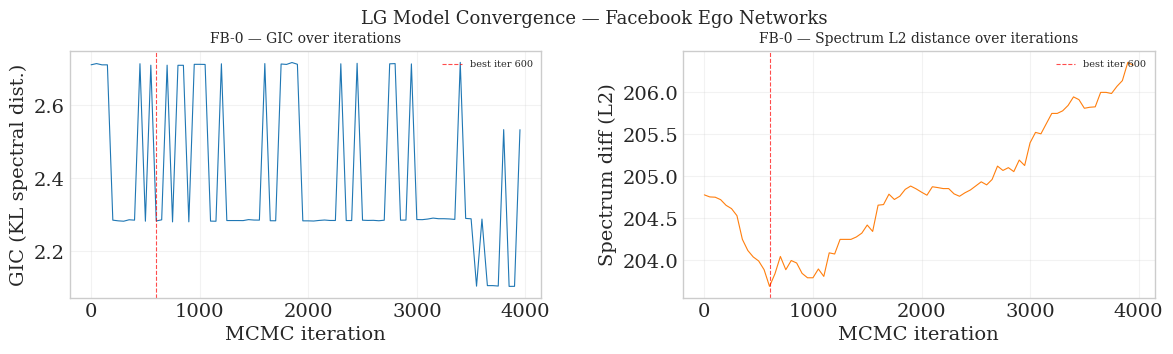

In [ ]:
n_nets = len(convergence_data)
fig, axes = plt.subplots(n_nets, 2, figsize=(14, 3.2 * n_nets), sharex=False,
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.3})
if n_nets == 1:
    axes = axes[np.newaxis, :]

for row, (ds_name, conv) in enumerate(convergence_data.items()):
    iters = conv['iterations']
    gic_vals = conv['gic_values']
    spec_diffs = conv['spectrum_diffs']
    best_it = conv['best_iteration']

    ax = axes[row, 0]
    ax.plot(iters, gic_vals, linewidth=0.8, color='tab:blue')
    ax.axvline(best_it, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label=f'best iter {best_it}')
    ax.set_ylabel('GIC (KL spectral dist.)')
    ax.set_title(f'{ds_name} — GIC over iterations', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.25)

    ax = axes[row, 1]
    ax.plot(iters, spec_diffs, linewidth=0.8, color='tab:orange')
    ax.axvline(best_it, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label=f'best iter {best_it}')
    ax.set_ylabel('Spectrum diff (L2)')
    ax.set_title(f'{ds_name} — Spectrum L2 distance over iterations', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.25)

for ax in axes[-1]:
    ax.set_xlabel('MCMC iteration')

plt.suptitle('LG Model Convergence — Facebook Ego Networks', fontsize=13, y=1.01)
plt.savefig(os.path.join(OUT_DIR, 'lg_convergence_per_network.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(OUT_DIR, 'lg_convergence_per_network.png'), bbox_inches='tight', dpi=150)
plt.show()

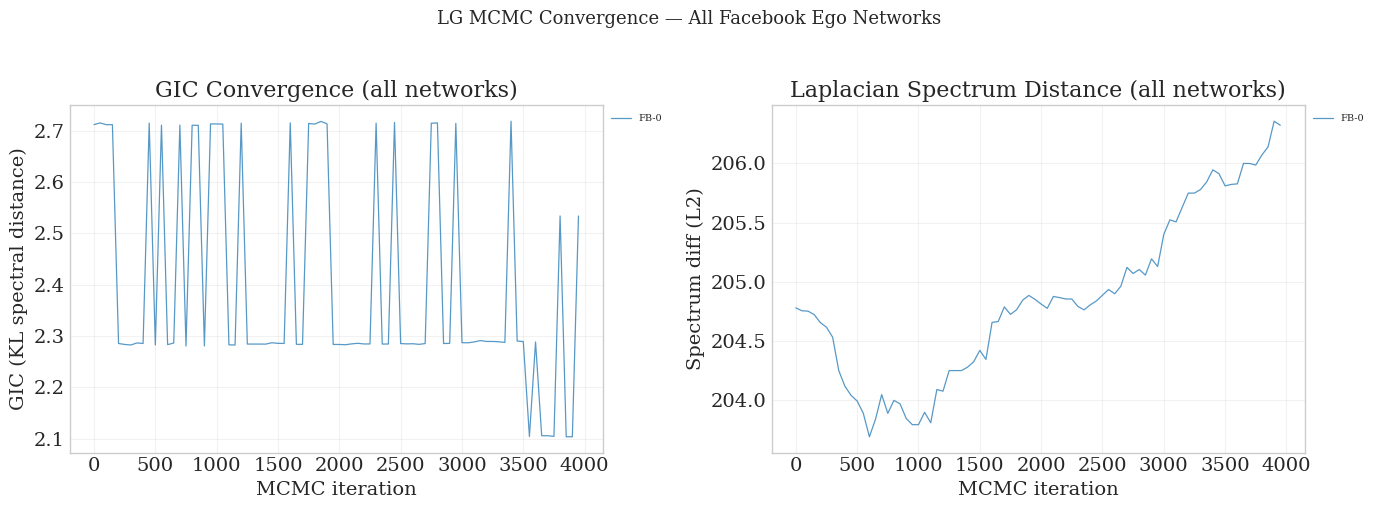

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ds_name, conv in convergence_data.items():
    iters = conv['iterations']
    ax1.plot(iters, conv['gic_values'], linewidth=0.9, alpha=0.75, label=ds_name)
    ax2.plot(iters, conv['spectrum_diffs'], linewidth=0.9, alpha=0.75, label=ds_name)

ax1.set_xlabel('MCMC iteration')
ax1.set_ylabel('GIC (KL spectral distance)')
ax1.set_title('GIC Convergence (all networks)')
ax1.legend(fontsize=7, bbox_to_anchor=(1.0, 1), loc='upper left')
ax1.grid(True, alpha=0.25)

ax2.set_xlabel('MCMC iteration')
ax2.set_ylabel('Spectrum diff (L2)')
ax2.set_title('Laplacian Spectrum Distance (all networks)')
ax2.legend(fontsize=7, bbox_to_anchor=(1.0, 1), loc='upper left')
ax2.grid(True, alpha=0.25)

plt.suptitle('LG MCMC Convergence — All Facebook Ego Networks', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'lg_convergence_overlay.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(OUT_DIR, 'lg_convergence_overlay.png'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Results

### 5.1 Mean GIC Ranking Across Ego Networks (Table 2 Extension)

In [ ]:
rank_rows = []
for ds_name in datasets:
    sub = df[(df['dataset'] == ds_name) & (df['model'] != 'Real')].copy()
    sub['gic_rank'] = sub['gic'].rank()
    sub['ks_rank'] = sub['ks_degree'].rank()
    for _, r in sub.iterrows():
        rank_rows.append({
            'dataset': ds_name, 'model': r['model'],
            'gic': r['gic'],
            'gic_rank': r['gic_rank'], 'ks_rank': r['ks_rank'],
        })

df_ranks = pd.DataFrame(rank_rows)

print('Mean Rank across Facebook ego networks (1 = best):')
mean_stats = df_ranks.groupby('model')[['gic', 'gic_rank', 'ks_rank']].mean()
mean_stats.columns = ['GIC Value', 'GIC Rank (spectral)', 'KS Rank (degree dist.)']
mean_stats = mean_stats.sort_values('GIC Rank (spectral)')
display(mean_stats.style.format('{:.2f}'))

Mean Rank across Facebook ego networks (1 = best):


,GIC Value,GIC Rank (spectral),KS Rank (degree dist.)
model,,,
Chung-Lu,5.32,1.00,2.00
Config,5.49,2.00,1.00
ER,6.35,3.00,6.00
LG,6.69,4.00,5.00
BA,6.96,5.00,4.00
WS,9.12,6.00,7.00
SBM,218.52,7.00,3.00


### 5.2 KS Statistic on Degree Distributions

In [ ]:
pivot_ks = df[df['model'] != 'Real'].pivot_table(index='dataset', columns='model', values='ks_degree')
cols = [m for m in model_order if m in pivot_ks.columns]
pivot_ks = pivot_ks[cols]

def highlight_min(row):
    is_min = row == row.min()
    return ['font-weight: bold' if v else '' for v in is_min]

print('Degree-distribution KS statistic per ego network (lower = better):')
display(pivot_ks.style.apply(highlight_min, axis=1).format('{:.4f}', na_rep='-'))

Degree-distribution KS statistic per ego network (lower = better):


model,LG,ER,BA,WS,SBM,Config,Chung-Lu
dataset,,,,,,,
FB-0,0.4006,0.4222,0.3934,0.5886,0.1790,0.0336,0.0529


### 5.3 Structural Deviation from Real Networks

In [ ]:
STRUCT_COLS = ['avg_clustering', 'transitivity', 'assortativity', 'modularity', 'triangles', 'n_communities']

deviation_rows = []
for ds_name in datasets:
    sub = df[df['dataset'] == ds_name].set_index('model')
    if 'Real' not in sub.index:
        continue
    real = sub.loc['Real']
    for model in sub.index:
        if model == 'Real':
            continue
        row = {'dataset': ds_name, 'model': model}
        for col in STRUCT_COLS:
            r_val, m_val = real[col], sub.loc[model, col]
            if pd.notna(r_val) and pd.notna(m_val) and r_val != 0:
                row[col] = abs(m_val - r_val) / abs(r_val)
            else:
                row[col] = np.nan
        deviation_rows.append(row)

df_dev = pd.DataFrame(deviation_rows)

print('Mean relative deviation per model across all Facebook ego networks:')
mean_dev = df_dev.groupby('model')[STRUCT_COLS].mean()
mean_dev = mean_dev.reindex([m for m in model_order if m in mean_dev.index])
display(mean_dev.style.format('{:.4f}', na_rep='-').background_gradient(cmap='RdYlGn_r', axis=None))

Mean relative deviation per model across all Facebook ego networks:


,avg_clustering,transitivity,assortativity,modularity,triangles,n_communities
model,,,,,,
LG,0.9138,0.8960,0.9686,0.5070,0.9512,0.3571
ER,0.9128,0.8951,1.0076,0.5172,0.9485,0.3000
BA,0.7711,0.7645,1.2828,0.5565,0.8062,0.4286
WS,0.0115,0.1943,0.9743,0.4868,0.3654,0.3714
SBM,0.5995,0.5679,1.4860,0.0123,0.7218,0.0429
Config,0.7509,0.6864,1.1719,0.5494,0.7587,0.3571
Chung-Lu,0.6623,0.5587,1.0619,0.6031,0.5484,0.9143


## 6. Visualizations

In [ ]:
models_to_plot = [m for m in model_order if m != 'Real']
colors = plt.cm.Set2(np.linspace(0, 1, len(models_to_plot)))
color_map = dict(zip(models_to_plot, colors))

n_ego = len(datasets)
ncols = min(5, n_ego)
nrows = (n_ego + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharey=False)
axes = np.atleast_2d(axes).flatten()

for idx, ds_name in enumerate(datasets):
    ax = axes[idx]
    sub = df[(df['dataset'] == ds_name) & (df['model'] != 'Real')].set_index('model')
    sub = sub.reindex([m for m in models_to_plot if m in sub.index])
    ax.bar(
        range(len(sub)), sub['gic'],
        yerr=sub.get('gic_std', 0), capsize=2,
        color=[color_map[m] for m in sub.index], edgecolor='black', linewidth=0.4
    )
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=60, ha='right', fontsize=8)
    ax.set_title(ds_name, fontsize=10)
    if idx % ncols == 0:
        ax.set_ylabel('GIC')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('GIC Comparison — Facebook Ego Networks', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'gic_all_baselines_facebook.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
ncols = min(5, n_ego)
nrows = (n_ego + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).flatten()

for idx, ds_name in enumerate(datasets):
    ax = axes[idx]
    cdfs = degree_cdfs.get(ds_name, {})
    for model_name, degs in cdfs.items():
        sorted_d = np.sort(degs)
        cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
        lw = 2.5 if model_name == 'Real' else 1.0
        ls = '-' if model_name in ('Real', 'LG', 'SBM', 'Config', 'Chung-Lu') else '--'
        ax.plot(sorted_d, 1 - cdf, label=model_name, linewidth=lw, linestyle=ls)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel('$k$')
    if idx % ncols == 0:
        ax.set_ylabel('$P(K \\geq k)$')
    ax.legend(fontsize=6, loc='lower left')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Degree CCDF — Facebook Ego Networks', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'degree_ccdf_facebook.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

mean_dev_plot = mean_dev.copy()
mean_dev_plot.columns = [c.replace('_', ' ').title() for c in mean_dev_plot.columns]
im = ax.imshow(mean_dev_plot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=2)

ax.set_xticks(range(len(mean_dev_plot.columns)))
ax.set_xticklabels(mean_dev_plot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(mean_dev_plot.index)))
ax.set_yticklabels(mean_dev_plot.index)

for i in range(len(mean_dev_plot.index)):
    for j in range(len(mean_dev_plot.columns)):
        val = mean_dev_plot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if val > 1.0 else 'black')

plt.colorbar(im, ax=ax, label='Mean Relative Deviation from Real')
ax.set_title('Structural Deviation Heatmap — Facebook Ego Networks')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'structural_deviation_heatmap_facebook.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Results

In [ ]:
df.to_csv(os.path.join(OUT_DIR, 'facebook_all_baselines_results.csv'), index=False)
df_dev.to_csv(os.path.join(OUT_DIR, 'facebook_structural_deviation.csv'), index=False)
df_ranks.to_csv(os.path.join(OUT_DIR, 'facebook_model_ranks.csv'), index=False)

with open(os.path.join(OUT_DIR, 'facebook_degree_cdfs.pkl'), 'wb') as f:
    pickle.dump(degree_cdfs, f)

print('All results saved to:', OUT_DIR)